In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

# Membuat data sintetis: y = 3x + 2 + noise
np.random.seed(42)                       # agar hasil bisa direproduksi (opsional tapi disarankan)
X = np.random.rand(100, 1) * 10         # 100 titik data, fitur antara 0–10
y = 3*X[:, 0] + 2 + np.random.randn(100) # target = 3x + 2, ditambah noise acak

# Membagi data: 80% latih, 20% uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Melatih model lalu memprediksi data uji
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluasi: R² mendekati 1 = bagus, RMSE mendekati 0 = bagus
print("R2:", round(r2_score(y_test, y_pred), 3))
print("RMSE:", round(root_mean_squared_error(y_test, y_pred), 3))

R2: 0.992
RMSE: 0.809


In [15]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Dataset California Housing: ~20 ribu rumah, 8 fitur, target = median harga rumah.
data = fetch_california_housing(as_frame=True)
X = data.frame.drop(columns=["MedHouseVal"])  # semua kolom kecuali target
y = data.frame["MedHouseVal"]                  # kolom target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)

# model.score() mengembalikan R² secara langsung
print("R2 test:", round(model.score(X_test, y_test), 3))

R2 test: 0.576


In [16]:
from sklearn.preprocessing import PolynomialFeatures

# degree=2 berarti: tambahkan kolom x² di samping x.
# include_bias=False berarti tidak menambah kolom konstanta (sudah ditangani LinearRegression).
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train[[X.columns[0]]])  # fit + transform data latih
X_test_poly = poly.transform(X_test[[X.columns[0]]])          # transform saja data uji

poly_model = LinearRegression().fit(X_train_poly, y_train)
print("R2 poly:", round(poly_model.score(X_test_poly, y_test), 3))

R2 poly: 0.463


# Analisis Perbandingan Model Regresi pada Dataset Iris

## Tujuan
Praktikum ini bertujuan untuk memahami perbedaan performa antara Simple Linear Regression, Multiple Linear Regression, dan Polynomial Regression.
Selain itu, praktikum ini juga bertujuan untuk melihat bagaimana jumlah fitur dan derajat polynomial mempengaruhi hasil prediksi terhadap variabel petal length.

## Langkah Kerja

Langkah-langkah yang dilakukan dalam praktikum ini adalah:
1. Mengimpor library yang dibutuhkan untuk analisis data.
2. Memuat dataset Iris dari sklearn.
3. Mengubah dataset menjadi DataFrame menggunakan pandas.
4. Menentukan variabel target yang akan diprediksi.
5. Membagi data menjadi data latih dan data uji.
6. Membuat model Simple Linear Regression.
7. Membuat model Multiple Linear Regression.
8. Membuat model Polynomial Regression.
9. Melakukan evaluasi model menggunakan MAE, RMSE, dan R2 Score.
10. Menampilkan hasil evaluasi dalam bentuk tabel dan grafik.

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


## Import Library

Pada tahap ini saya mengimpor library yang dibutuhkan.
Pandas digunakan untuk mengelola data, numpy untuk perhitungan numerik, matplotlib dan seaborn untuk visualisasi, serta sklearn untuk membuat dan mengevaluasi model regresi.

In [18]:
# PREPARASI DATA (Dilakukan sekali di awal)

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
y = df['petal length (cm)']

# Split Data (80% latih, 20% uji)
# Untuk Simple & Poly (1 Fitur: Petal Width)
X_s = df[['petal width (cm)']]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y, test_size=0.2, random_state=42)

# Untuk Multiple (3 Fitur)
X_m = df[['sepal length (cm)', 'sepal width (cm)', 'petal width (cm)']]
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_m, y, test_size=0.2, random_state=42)



## Preparasi Data

Pada bagian ini saya memuat dataset Iris menggunakan fungsi load_iris(). Dataset tersebut kemudian diubah menjadi DataFrame menggunakan pandas agar lebih mudah dianalisis. Variabel petal length dijadikan sebagai target yang akan diprediksi oleh model.
Selanjutnya data dibagi menjadi data training dan data testing dengan perbandingan 80% data latih dan 20% data uji. Untuk model simple dan polynomial regression digunakan satu fitur yaitu petal width, sedangkan untuk multiple regression digunakan tiga fitur yaitu sepal length, sepal width, dan petal width.

In [19]:
# 1. SIMPLE LINEAR REGRESSION

print("=== NOMOR 1: SIMPLE LINEAR REGRESSION ===")
model_s = LinearRegression().fit(X_train_s, y_train_s)
y_pred_s = model_s.predict(X_test_s)

print(f"Hasil Prediksi Selesai.")
print(f"R2 Score Simple: {r2_score(y_test_s, y_pred_s):.4f}")



=== NOMOR 1: SIMPLE LINEAR REGRESSION ===
Hasil Prediksi Selesai.
R2 Score Simple: 0.9286


## 1. Simple Linear Regression

Pada bagian ini saya membuat model Simple Linear Regression menggunakan satu fitur yaitu petal width untuk memprediksi petal length. Model dilatih menggunakan data training kemudian digunakan untuk melakukan prediksi pada data testing. Setelah itu dihitung nilai R2 Score untuk mengetahui tingkat akurasi model.

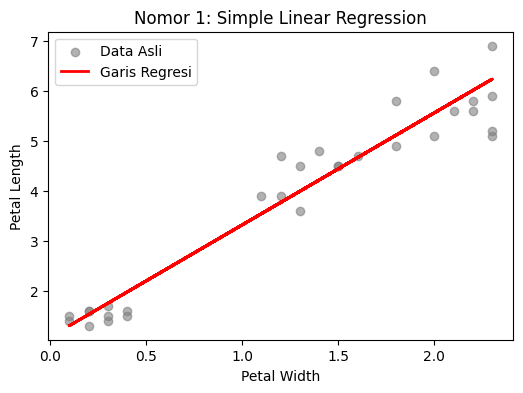

In [20]:
# Visualisasi Garis Regresi
plt.figure(figsize=(6, 4))
plt.scatter(X_test_s, y_test_s, color='gray', alpha=0.6, label='Data Asli')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Garis Regresi')
plt.title('Nomor 1: Simple Linear Regression')
plt.xlabel('Petal Width')
plt.ylabel('Petal Length')
plt.legend()
plt.show()

Output yang dihasilkan berupa nilai R2 Score yang menunjukkan tingkat akurasi model dalam memprediksi data. Selain itu juga ditampilkan grafik yang memperlihatkan hubungan antara petal width dan petal length. Titik abu-abu menunjukkan data asli sedangkan garis merah menunjukkan garis regresi dari model.

In [21]:
# 2. MULTIPLE LINEAR REGRESSION

print("\n=== NOMOR 2: MULTIPLE LINEAR REGRESSION ===")
model_m = LinearRegression().fit(X_train_m, y_train_m)
y_pred_m = model_m.predict(X_test_m)

print(f"Fitur yang digunakan: {list(X_m.columns)}")
print(f"R2 Score Multiple: {r2_score(y_test_m, y_pred_m):.4f}")
print("Status: Berhasil memproses 3 fitur sekaligus.")


=== NOMOR 2: MULTIPLE LINEAR REGRESSION ===
Fitur yang digunakan: ['sepal length (cm)', 'sepal width (cm)', 'petal width (cm)']
R2 Score Multiple: 0.9603
Status: Berhasil memproses 3 fitur sekaligus.


Pada bagian ini saya membuat model Multiple Linear Regression yang menggunakan tiga fitur sekaligus yaitu sepal length, sepal width, dan petal width untuk memprediksi nilai petal length.

nah, output yang dihasilkan menunjukkan fitur yang digunakan dalam model serta nilai R2 Score. Nilai tersebut digunakan untuk melihat seberapa baik model dalam memprediksi data dengan menggunakan beberapa variabel input sekaligus.

In [22]:
# 3. POLYNOMIAL REGRESSION (DEGREE 1 VS 2)
# Transformasi ke Degree 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_s)
X_test_poly = poly.transform(X_test_s)

model_p = LinearRegression().fit(X_train_poly, y_train_s)
y_pred_p = model_p.predict(X_test_poly)

print(f"R2 Degree 1 (Linear): {r2_score(y_test_s, y_pred_s):.4f}")
print(f"R2 Degree 2 (Poly)  : {r2_score(y_test_s, y_pred_p):.4f}")
print("Kesimpulan: Degree 2 lebih baik karena menangkap pola melengkung pada data.")

R2 Degree 1 (Linear): 0.9286
R2 Degree 2 (Poly)  : 0.9422
Kesimpulan: Degree 2 lebih baik karena menangkap pola melengkung pada data.


Pada bagian ini saya menggunakan Polynomial Regression dengan degree 2. Fitur petal width diubah menjadi bentuk polynomial sehingga model dapat mempelajari hubungan yang lebih kompleks antara variabel input dan output.

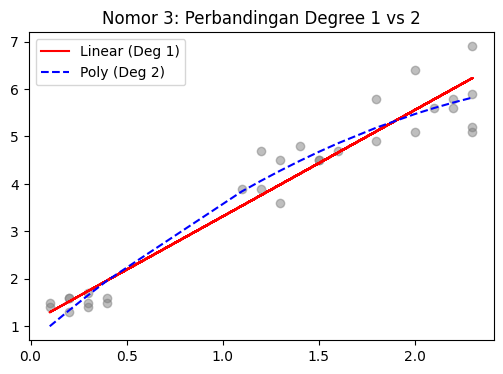

In [23]:
# Visualisasi Perbandingan Garis
plt.figure(figsize=(6, 4))
plt.scatter(X_test_s, y_test_s, color='gray', alpha=0.5)
plt.plot(X_test_s, y_pred_s, color='red', label='Linear (Deg 1)')

sorted_idx = np.argsort(X_test_s.iloc[:, 0])
plt.plot(X_test_s.iloc[sorted_idx], y_pred_p[sorted_idx], color='blue', linestyle='--', label='Poly (Deg 2)')
plt.title('Nomor 3: Perbandingan Degree 1 vs 2')
plt.legend()
plt.show()

Nah di sini output menunjukan perbandingan nilai R2 Score antara model linear dan polynomial. Grfik tersebut juga menampilkan dua garis yang menunjukan perbedaan bentuk hubungan antar regresi linear dan polynomial

In [24]:
# 4. LAPORAN EVALUASI AKHIR (MAE, RMSE, R2)

print("\n=== NOMOR 4: LAPORAN EVALUASI AKHIR ===")

def get_metrics(y_true, y_pred):
    return [mean_absolute_error(y_true, y_pred),
            root_mean_squared_error(y_true, y_pred),
            r2_score(y_true, y_pred)]

laporan = pd.DataFrame({
    'Metrik': ['MAE', 'RMSE', 'R2'],
    'Simple (No 1)': get_metrics(y_test_s, y_pred_s),
    'Multiple (No 2)': get_metrics(y_test_m, y_pred_m),
    'Polynomial (No 3)': get_metrics(y_test_s, y_pred_p)
}).set_index('Metrik')

print(laporan.round(4))



=== NOMOR 4: LAPORAN EVALUASI AKHIR ===
        Simple (No 1)  Multiple (No 2)  Polynomial (No 3)
Metrik                                                   
MAE            0.3801           0.2605             0.3412
RMSE           0.4838           0.3606             0.4351
R2             0.9286           0.9603             0.9422


Pada bagian ini saya melakukan evaluasi terhadap semua model regresi menggunakan beberapa metrik yaitu MAE, RMSE, dan R2 Score. Hasil evaluasi ditampilkan dalam bentuk tabel agar lebih mudah dibandingkan.

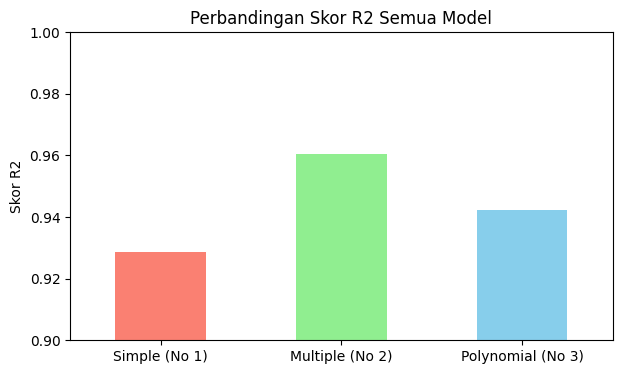


--- TUGAS SELESAI ---


In [25]:
# Visualisasi perbandingan akurasi
laporan.loc['R2'].plot(kind='bar', color=['salmon', 'lightgreen', 'skyblue'], figsize=(7, 4))
plt.title('Perbandingan Skor R2 Semua Model')
plt.ylabel('Skor R2')
plt.ylim(0.9, 1.0)
plt.xticks(rotation=0)
plt.show()

print("\n--- TUGAS SELESAI ---")

Output menampilkan tabel yang berisi nilai MAE, RMSE, dan R2 Score dari setiap model regresi. Grafik batang juga ditampilkan untuk memperlihatkan perbandingan nilai R2 Score dari masing-masing model sehingga lebih mudah melihat model mana yang memiliki performa terbaik.

##Kesimpulan
Berdasarkan dari hasil praktikum, saya dapat mengambil kesimpulan bahwa model regresi dapat digunakan untuk memprediksi nilai pada dataset. Simple Linear Regression menggunakan satu variabel input, Multiple Linear Regression menggunakan beberapa variabel input, sedangkan Polynomial Regression dapat menangkap hubungan data yang lebih kompleks. Dari hasil evaluasi menggunakan MAE, RMSE, dan R2 Score dapat dilihat bahwa setiap model memiliki tingkat performa yang berbeda dalam melakukan prediksi.
